In [16]:
import numpy as np
import json
import pandas as pd
from gensim.models import Word2Vec
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class Word2VecEmbeddingExtractor:
    def __init__(self, model_path):
        """
        Initialize the embedding extractor with Word2Vec model path.
        """
        self.model = Word2Vec.load(model_path)
        print("Word2Vec model loaded successfully.")

    def extract_embeddings(self, words_labels):
        """
        Extract embeddings for each word and associate it with the provided label.
        """
        embeddings = []
        labels = []
        word_list = []

        for word, label in words_labels:
            if word in self.model.wv:
                embedding = self.model.wv[word]
                embeddings.append(embedding)
                labels.append(label)
                word_list.append(word)
            else:
                print(f"Word '{word}' not found in Word2Vec vocabulary. Skipping.")

        embeddings = np.array(embeddings)
        labels = np.array(labels)

        # Save embeddings and labels
        np.save("embeddings_word2vec.npy", embeddings)
        np.save("labels_word2vec.npy", labels)

        # Save word mapping as JSON
        word_mapping = {
            "index": list(range(len(word_list))),
            "word": word_list,
            "label": labels.tolist()
        }
        with open("word_mapping_word2vec.json", "w") as f:
            json.dump(word_mapping, f, indent=4)

        print(f"Saved {len(word_list)} embeddings with labels and word mappings.")

        return embeddings, labels, word_list

In [ ]:

# Define the Word2Vec model path
model_path = "/Users/jonasklein/word2vec/trained_word2vec/word2vec_model"

# List of words and their labels
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0),
    ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0),
    ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1), ("grootmoeder", 0),
    ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0),
    ("jongen", 1), ("meisje", 0), ("jongetje", 1), ("meid", 0),
    ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0),
    ("peetvader", 1), ("peetmoeder", 0), ("bruidegom", 1), ("bruid", 0),
    ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1),
    ("dame", 0), ("kerel", 1), ("mister", 1), ("miss", 0),
    ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0),
    ("koning", 1), ("koningin", 0), ("lord", 1), ("lady", 0),
    ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0),
    ("mannelijk", 1), ("vrouwelijk", 0), ("gentleman", 1), ("gozer", 1),
    ("wijf", 0)
]

# Initialize the extractor
extractor = Word2VecEmbeddingExtractor(model_path)

# Process words and extract embeddings
embeddings, labels, word_list = extractor.extract_embeddings(words_labels)

# Verify shapes
print("Final embeddings shape:", embeddings.shape)
print("Final labels shape:", labels.shape)
print("Final word list length:", len(word_list))


Word2Vec model loaded successfully.
Saved 65 embeddings with labels and word mappings.
Final embeddings shape: (65, 200)
Final labels shape: (65,)
Final word list length: 65


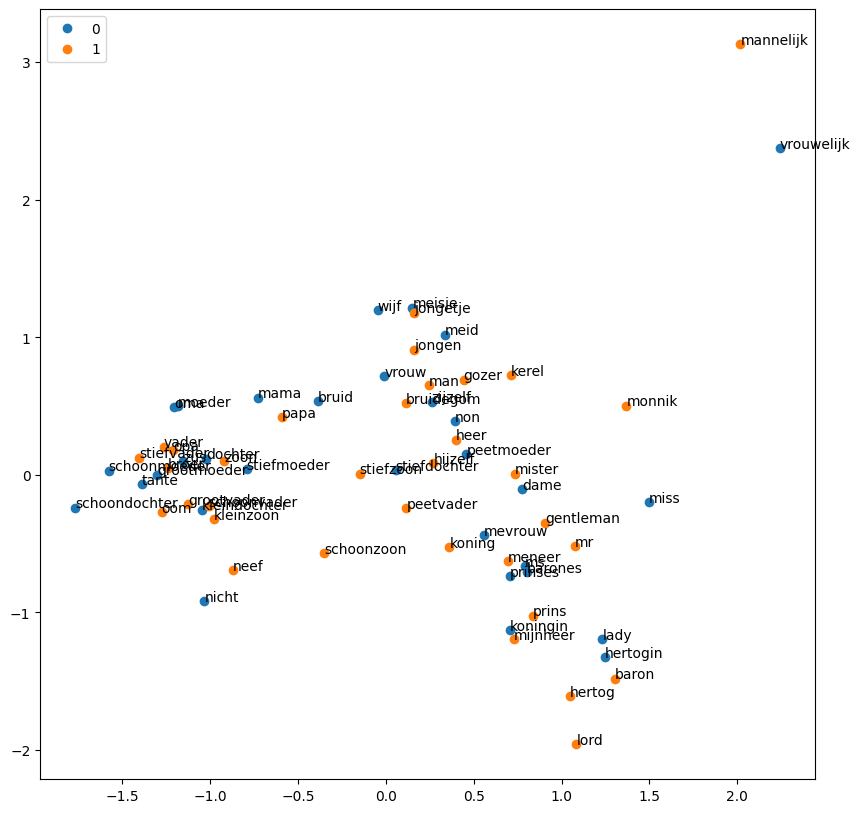

In [18]:
# Make a PCA plot of the embeddings
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

df = pd.DataFrame(pca_result, columns=["x", "y"])
df["label"] = labels
df["word"] = word_list

plt.figure(figsize=(10, 10))
groups = df.groupby("label")
for name, group in groups:
    plt.plot(group.x, group.y, marker="o", linestyle="", label=name)
    for i, txt in enumerate(group.word):
        plt.annotate(txt, (group.x.iloc[i], group.y.iloc[i]))

plt.legend()
plt.show()

Label distribution in the dataset:
label
1    34
0    31
Name: count, dtype: int64
Class balance: 0.9117647058823529
Percentage of majority class: 0.5230769230769231


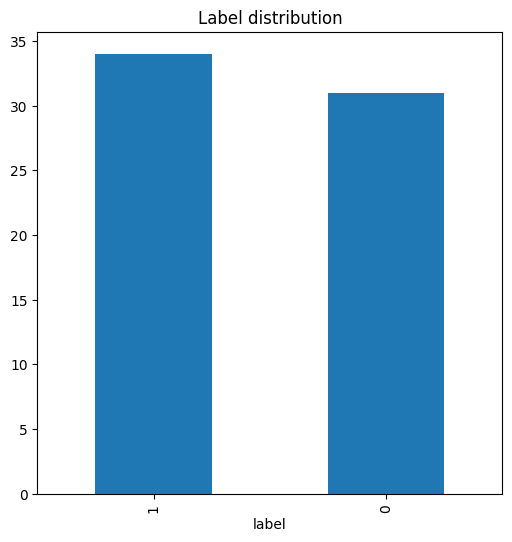

In [19]:
# Get label distribution in the dataset
label_distribution = df["label"].value_counts()
print("Label distribution in the dataset:")
print(label_distribution)
print("Class balance:", label_distribution[0] / label_distribution[1])
print("Percentage of majority class:", label_distribution[1] / label_distribution.sum())

# Visualize the label distribution
plt.figure(figsize=(6, 6))
label_distribution.plot(kind="bar", title="Label distribution")
plt.show()

In [25]:
# Load embeddings and labels
embeddings = np.load("embeddings_word2vec.npy")
labels = np.load("labels_word2vec.npy")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Initialize and train SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_classifier.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Female (0)", "Male (1)"]))


Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

  Female (0)       0.75      1.00      0.86         6
    Male (1)       1.00      0.71      0.83         7

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13



Label distribution in the test set:
1    7
0    6
Name: count, dtype: int64
Class balance: 0.8571428571428571
Percentage of majority class: 0.5384615384615384


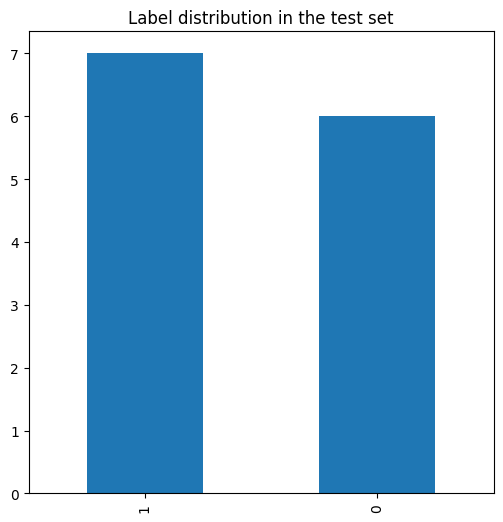

In [26]:
# Get label distribution in the test set
label_distribution = pd.Series(y_test).value_counts()
print("Label distribution in the test set:")
print(label_distribution)
print("Class balance:", label_distribution[0] / label_distribution[1])
print("Percentage of majority class:", label_distribution[1] / label_distribution.sum())

# Visualize the label distribution in the test set
plt.figure(figsize=(6, 6))
label_distribution.plot(kind="bar", title="Label distribution in the test set")
plt.show()

Class labels: [0 1]


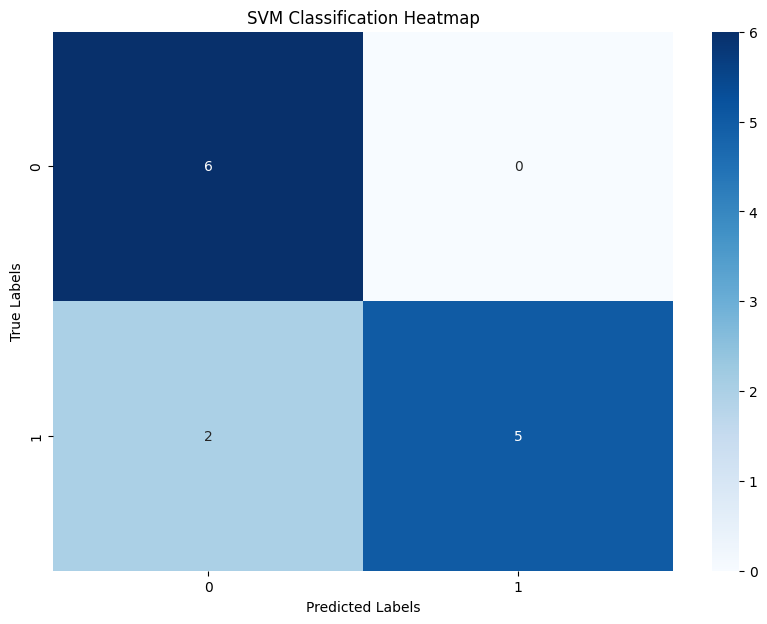

In [27]:
cm = confusion_matrix(y_test, y_pred)

# Unique class labels for annotation
class_labels = np.unique(labels)
print("Class labels:", class_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Classification Heatmap')
plt.show()